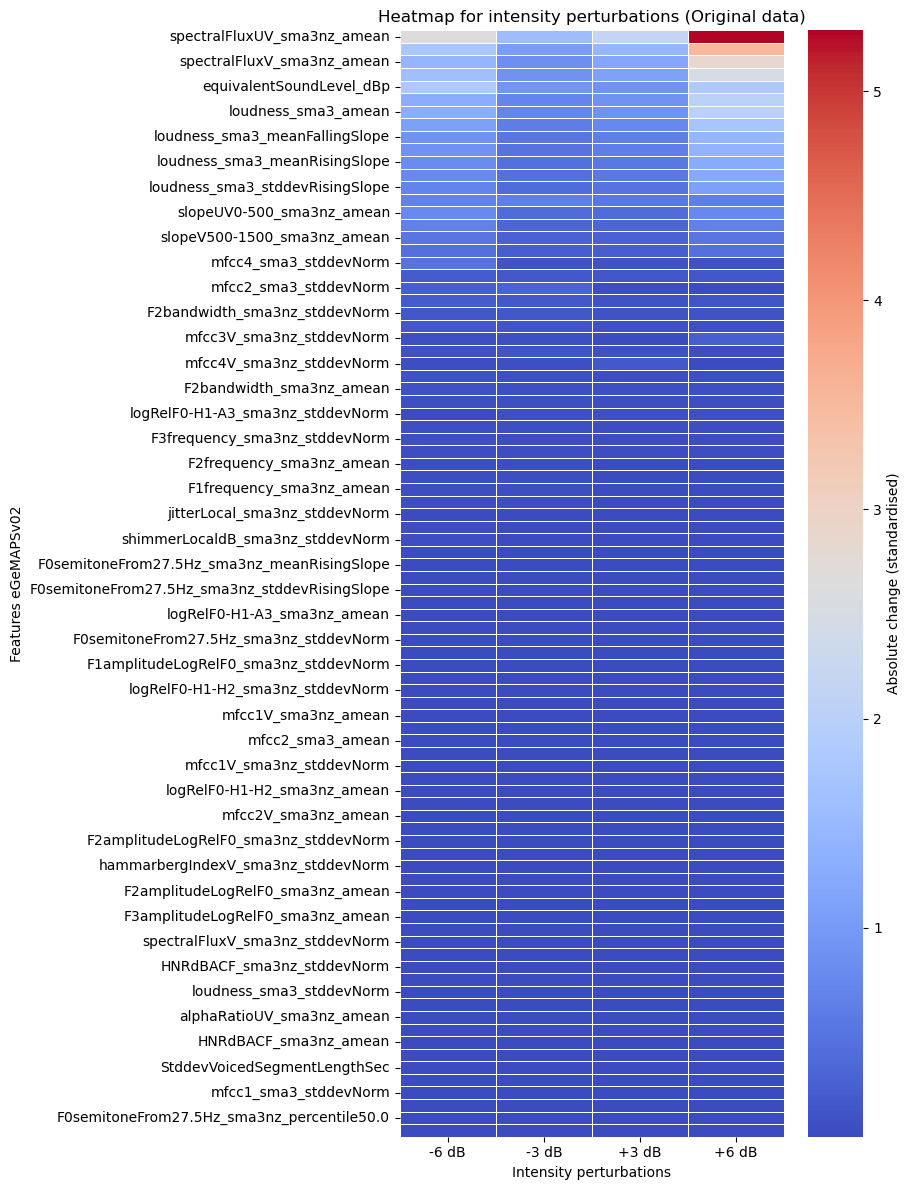

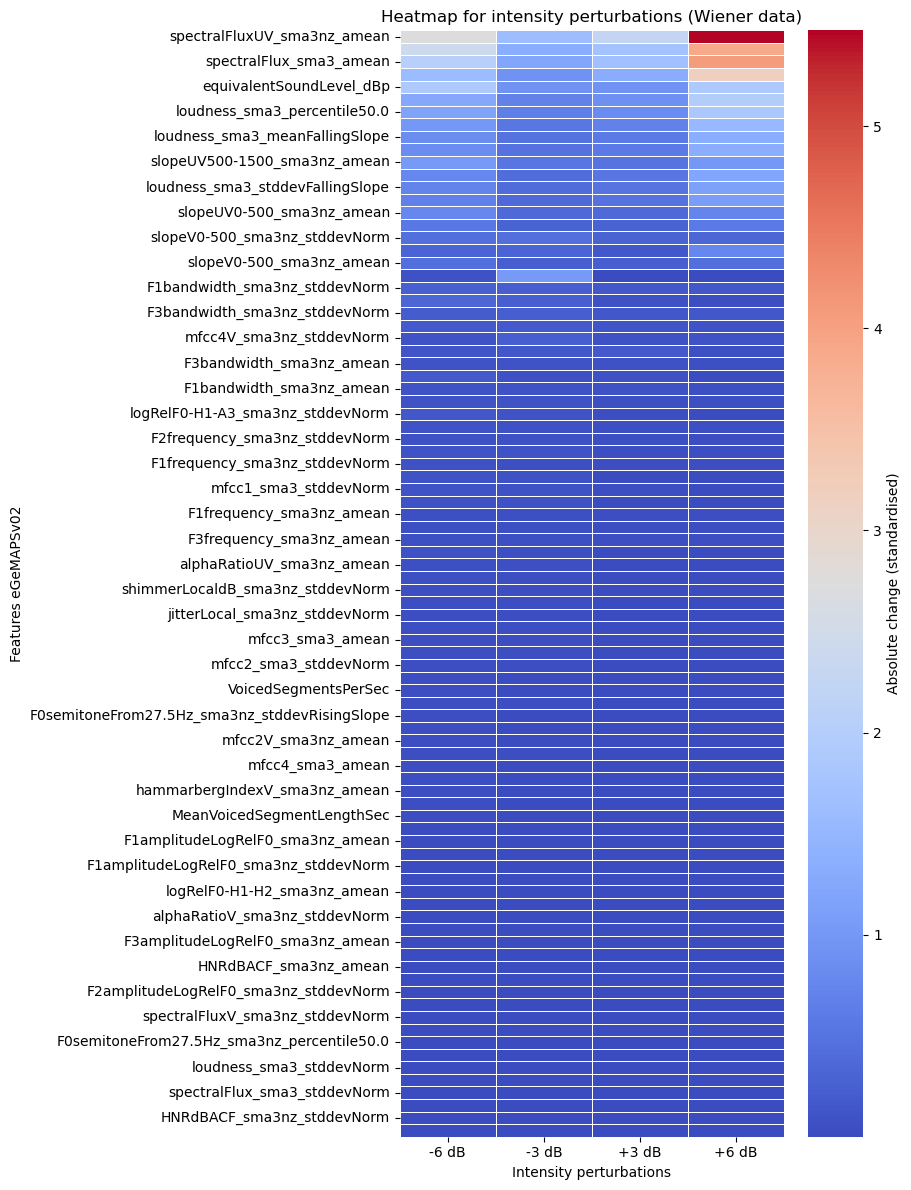

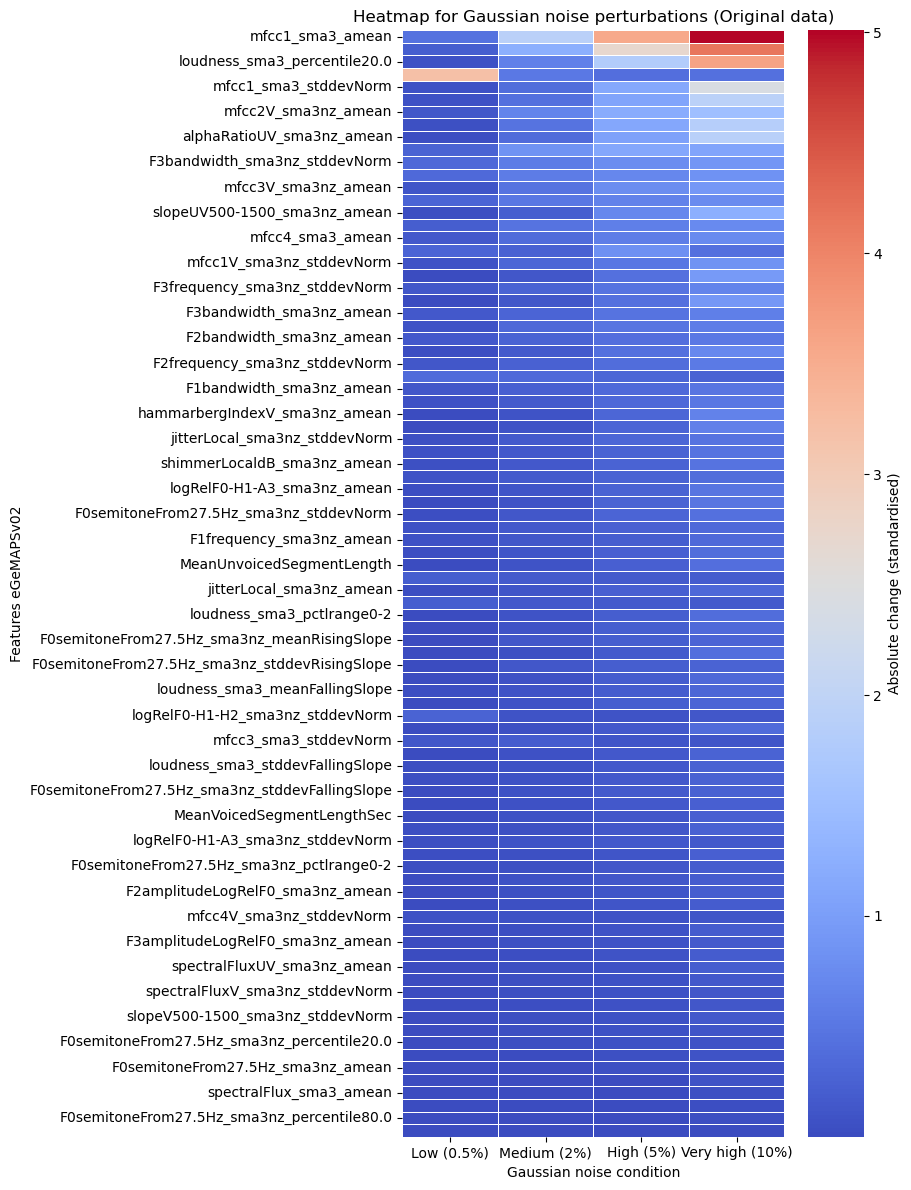

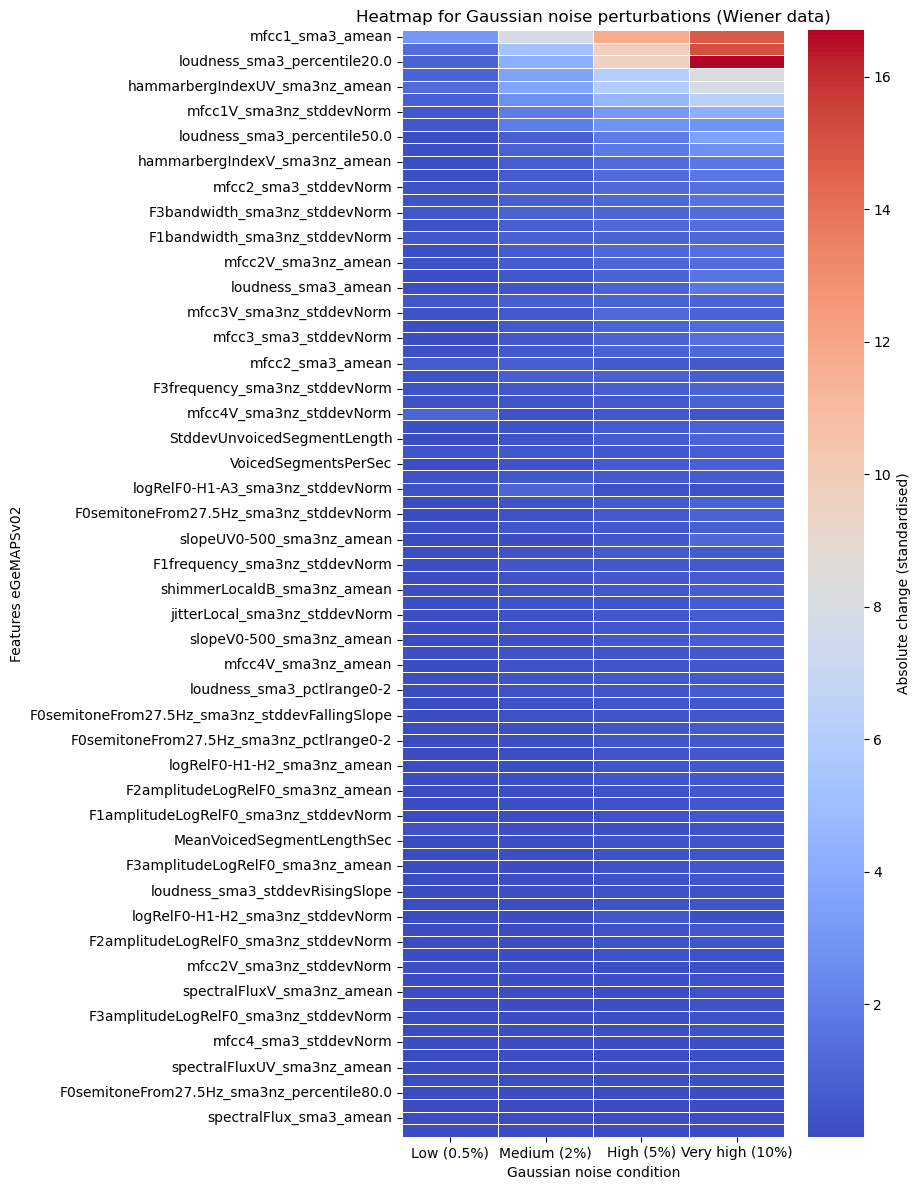

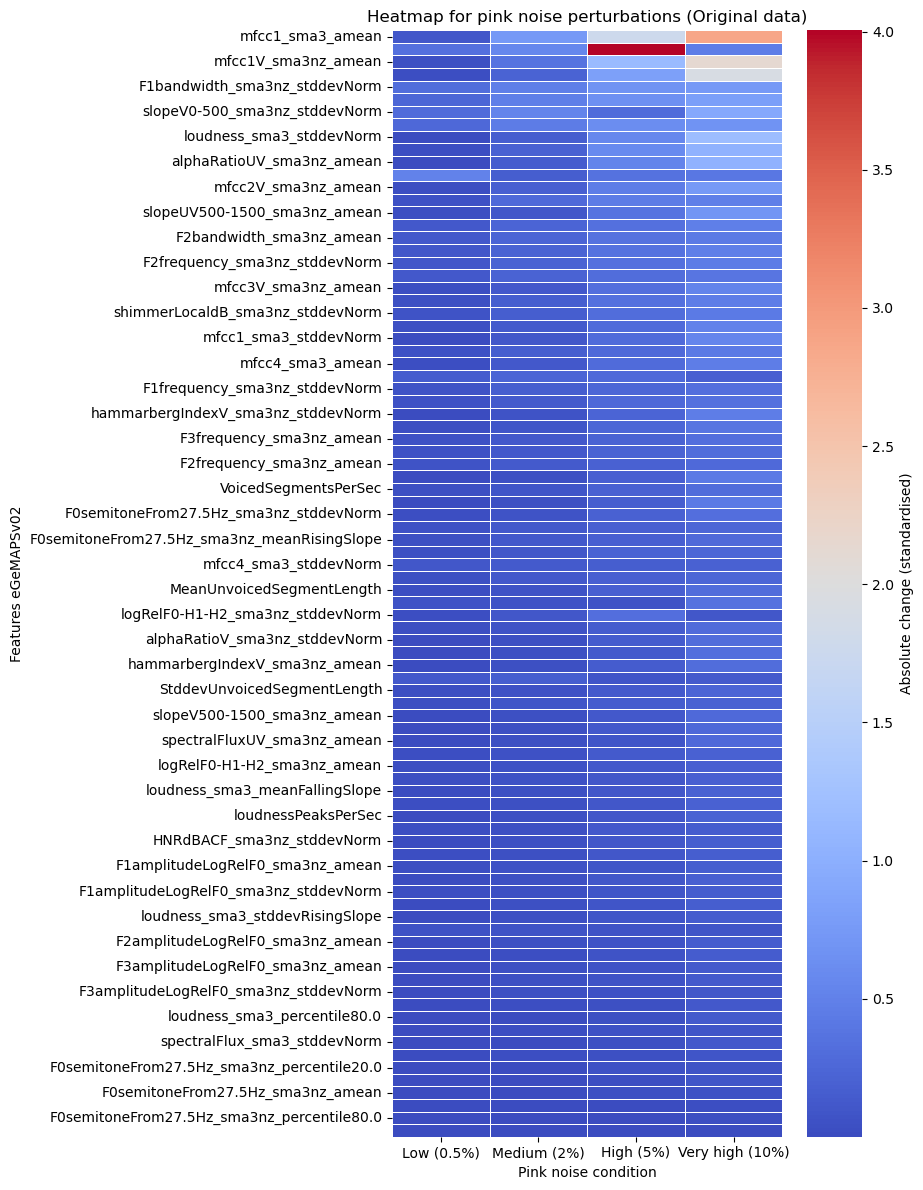

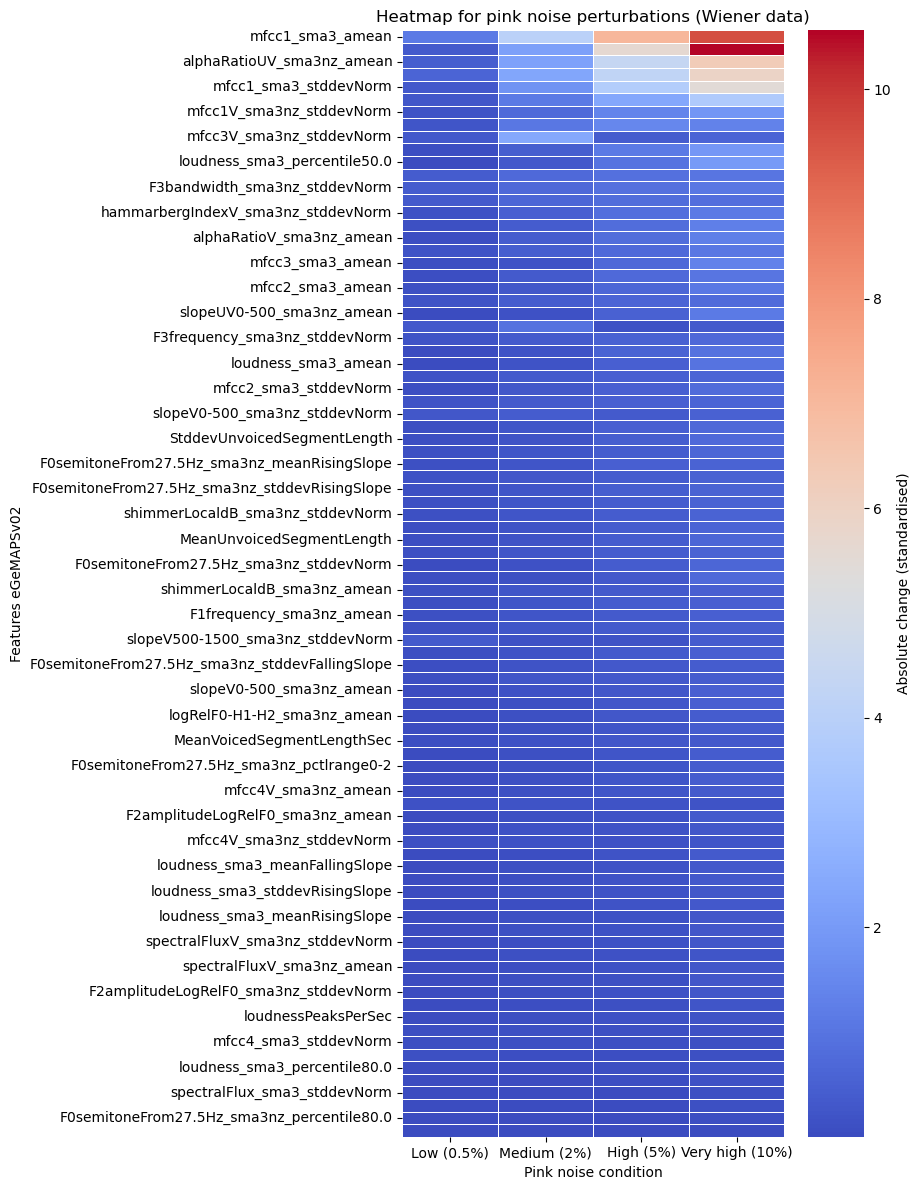

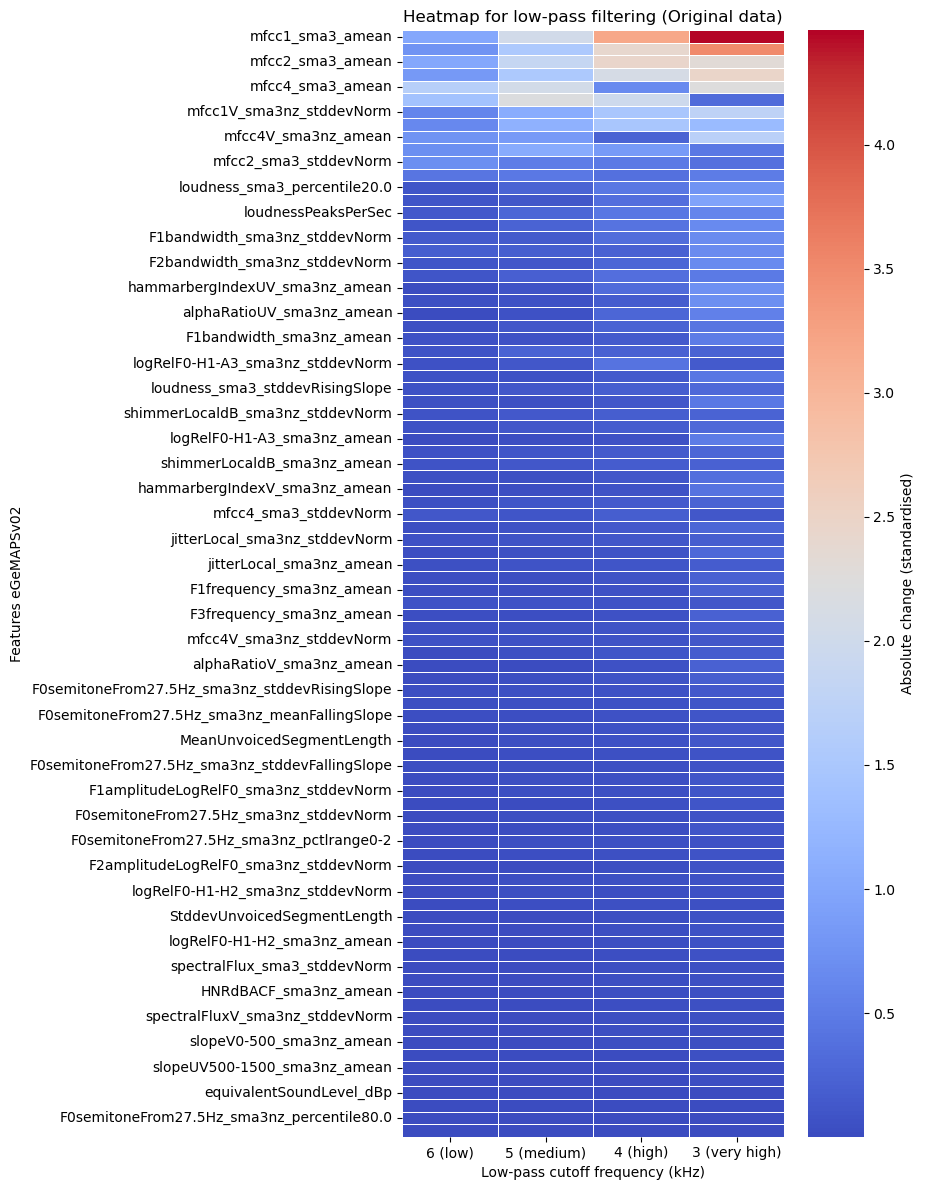

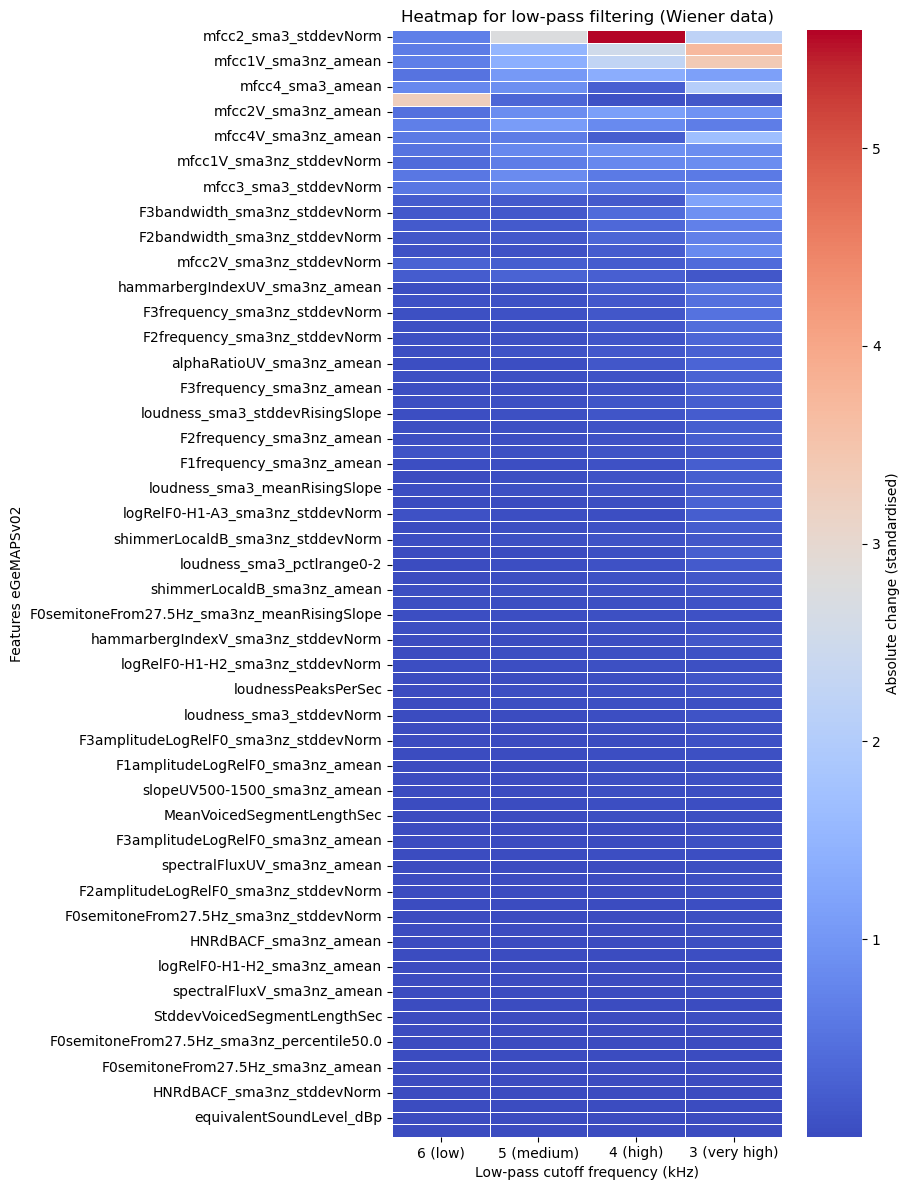

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#Input original:
#opensmile_original_features_pain_original
#opensmile_intensity_-6dB_features_pain_original
#opensmile_intensity_-3dB_features_pain_original
#opensmile_intensity_3dB_features_pain_original
#opensmile_intensity_6dB_features_pain_original
#opensmile_low_gaussian_features_pain_original
#opensmile_medium_gaussian_features_pain_original
#opensmile_high_gaussian_features_pain_original
#opensmile_very_high_gaussian_features_pain_original
#opensmile_low_pink_features_pain_original
#opensmile_medium_pink_features_pain_original
#opensmile_high_pink_features_pain_original
#opensmile_very_high_pink_features_pain_original
#opensmile_low_lowpass_features_pain_original
#opensmile_medium_lowpass_features_pain_original
#opensmile_high_lowpass_features_pain_original
#opensmile_very_high_lowpass_features_pain_original

#Input Wiener:
#opensmile_wiener_features_pain
#opensmile_intensity_-6dB_features_pain
#opensmile_intensity_-3dB_features_pain
#opensmile_intensity_3dB_features_pain
#opensmile_intensity_6dB_features_pain
#opensmile_low_gaussian_features_pain
#opensmile_medium_gaussian_features_pain
#opensmile_high_gaussian_features_pain
#opensmile_very_high_gaussian_features_pain
#opensmile_low_pink_features_pain
#opensmile_medium_pink_features_pain
#opensmile_high_pink_features_pain
#opensmile_very_high_pink_features_pain
#opensmile_low_lowpass_features_pain
#opensmile_medium_lowpass_features_pain
#opensmile_high_lowpass_features_pain
#opensmile_very_high_lowpass_features_pain


# =========================
# Paths
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

# =========================
# Configuratie
# =========================
ROBUSTNESS_CONFIG = {
    "intensity": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "-6 dB": {
                "original": "opensmile_intensity_-6dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_-6dB_features_pain.csv",
            },
            "-3 dB": {
                "original": "opensmile_intensity_-3dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_-3dB_features_pain.csv",
            },
            "+3 dB": {
                "original": "opensmile_intensity_3dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_3dB_features_pain.csv",
            },
            "+6 dB": {
                "original": "opensmile_intensity_6dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_6dB_features_pain.csv",
            },
        },
        "xlabel": "Intensity perturbations",
        "title": "Heatmap for intensity perturbations",
    },
    "gaussian_noise": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_low_gaussian_features_pain_original.csv",
                "wiener": "opensmile_low_gaussian_features_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_medium_gaussian_features_pain_original.csv",
                "wiener": "opensmile_medium_gaussian_features_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_high_gaussian_features_pain_original.csv",
                "wiener": "opensmile_high_gaussian_features_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_very_high_gaussian_features_pain_original.csv",
                "wiener": "opensmile_very_high_gaussian_features_pain.csv",
            },
        },
        "xlabel": "Gaussian noise condition",
        "title": "Heatmap for Gaussian noise perturbations",
    },
    "pink_noise": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_low_pink_features_pain_original.csv",
                "wiener": "opensmile_low_pink_features_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_medium_pink_features_pain_original.csv",
                "wiener": "opensmile_medium_pink_features_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_high_pink_features_pain_original.csv",
                "wiener": "opensmile_high_pink_features_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_very_high_pink_features_pain_original.csv",
                "wiener": "opensmile_very_high_pink_features_pain.csv",
            },
        },
        "xlabel": "Pink noise condition",
        "title": "Heatmap for pink noise perturbations",
    },
    "lowpass": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "6 (low)": {
                "original": "opensmile_low_lowpass_features_pain_original.csv",
                "wiener": "opensmile_low_lowpass_features_pain.csv",
            },
            "5 (medium)": {
                "original": "opensmile_medium_lowpass_features_pain_original.csv",
                "wiener": "opensmile_medium_lowpass_features_pain.csv",
            },
            "4 (high)": {
                "original": "opensmile_high_lowpass_features_pain_original.csv",
                "wiener": "opensmile_high_lowpass_features_pain.csv",
            },
            "3 (very high)": {
                "original": "opensmile_very_high_lowpass_features_pain_original.csv",
                "wiener": "opensmile_very_high_lowpass_features_pain.csv",
            },
        },
        "xlabel": "Low-pass cutoff frequency (kHz)",
        "title": "Heatmap for low-pass filtering",
    },
}

EXCLUDE_COLS = ["participant_id", "filename", "file_path", "name"]


# =========================
# Functies
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def get_feature_cols(df, exclude_cols=None):
    exclude_cols = exclude_cols or []
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return [col for col in numeric_cols if col not in exclude_cols]


def validate_matching_ids(reference_df, comparison_dfs):
    reference_ids = reference_df[["participant_id", "filename"]]

    for name, df in comparison_dfs.items():
        current_ids = df[["participant_id", "filename"]]
        if not reference_ids.equals(current_ids):
            raise ValueError(f"Mismatch in {name}")


def standardize_against_reference(dfs, feature_cols, reference_key="original"):
    scaler = StandardScaler()
    scaler.fit(dfs[reference_key][feature_cols])

    dfs_std = {}
    for key, df in dfs.items():
        df_std = df.copy()
        df_std[feature_cols] = scaler.transform(df[feature_cols])
        dfs_std[key] = df_std

    return dfs_std


def compute_abs_diff_heatmap_df(dfs_std, feature_cols, condition_order, reference_key="original"):
    original_features = dfs_std[reference_key][feature_cols]
    abs_diff_means = {}

    for condition in condition_order:
        perturbed_features = dfs_std[condition][feature_cols]
        abs_diff = np.abs(perturbed_features - original_features)
        abs_diff_means[condition] = abs_diff.mean(axis=0)

    heatmap_df = pd.DataFrame(abs_diff_means)
    heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
    heatmap_df = heatmap_df.drop(columns=["mean_change"])

    return heatmap_df


def plot_heatmap(
    heatmap_df,
    title,
    xlabel,
    ylabel="Features eGeMAPSv02",
    top_n=88,
    figsize=(9, 12)
):
    heatmap_top = heatmap_df.head(top_n)

    plt.figure(figsize=figsize)
    sns.heatmap(
        heatmap_top,
        cmap="coolwarm",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Absolute change (standardised)"},
        annot=False
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def run_robustness_evaluation(base_path, config, data_type, top_n=88, save_csv=False):
    """
    data_type = 'original' of 'wiener'
    """
    files = {
        "original": base_path / config[data_type]
    }

    for condition_name, paths in config["conditions"].items():
        files[condition_name] = base_path / paths[data_type]

    dfs = {name: load_and_sort_csv(path) for name, path in files.items()}

    validate_matching_ids(
        reference_df=dfs["original"],
        comparison_dfs={k: v for k, v in dfs.items() if k != "original"}
    )

    feature_cols = get_feature_cols(dfs["original"], exclude_cols=EXCLUDE_COLS)
    dfs_std = standardize_against_reference(dfs, feature_cols, reference_key="original")

    condition_order = list(config["conditions"].keys())
    heatmap_df = compute_abs_diff_heatmap_df(
        dfs_std=dfs_std,
        feature_cols=feature_cols,
        condition_order=condition_order,
        reference_key="original"
    )

    if save_csv:
        output_name = f"robustness_{data_type}_{config['title'].lower().replace(' ', '_')}.csv"
        heatmap_df.to_csv(base_path / output_name)

    plot_heatmap(
        heatmap_df=heatmap_df,
        title=f"{config['title']} ({data_type.capitalize()} data)",
        xlabel=config["xlabel"],
        top_n=top_n
    )

    return heatmap_df


# =========================
# Alles runnen
# =========================
results = {}

for perturbation_name, config in ROBUSTNESS_CONFIG.items():
    results[(perturbation_name, "original")] = run_robustness_evaluation(
        base_path=BASE_PATH,
        config=config,
        data_type="original",
        top_n=88,
        save_csv=False
    )

    results[(perturbation_name, "wiener")] = run_robustness_evaluation(
        base_path=BASE_PATH,
        config=config,
        data_type="wiener",
        top_n=88,
        save_csv=False
    )

For only the selected features heatmaps 

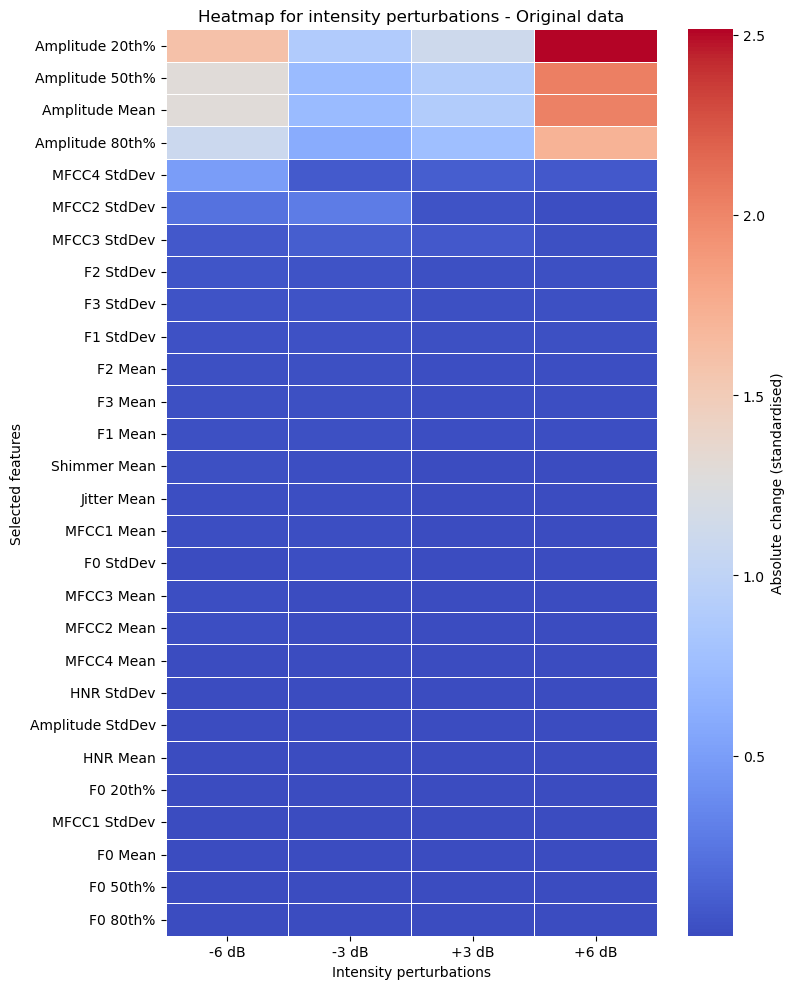

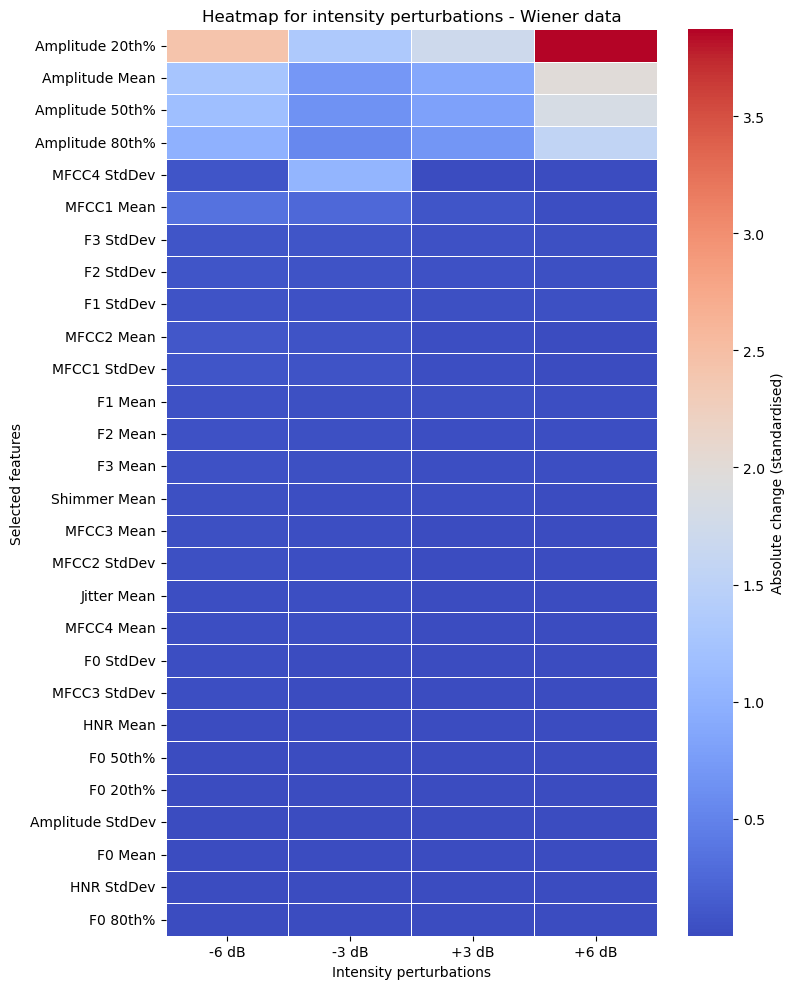

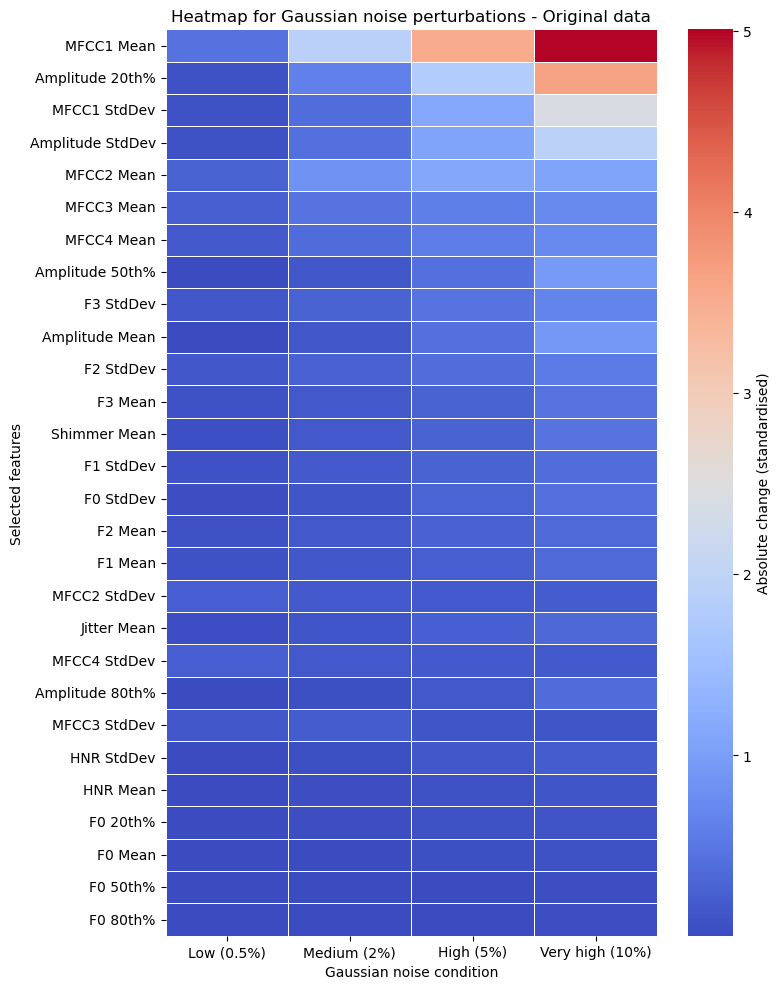

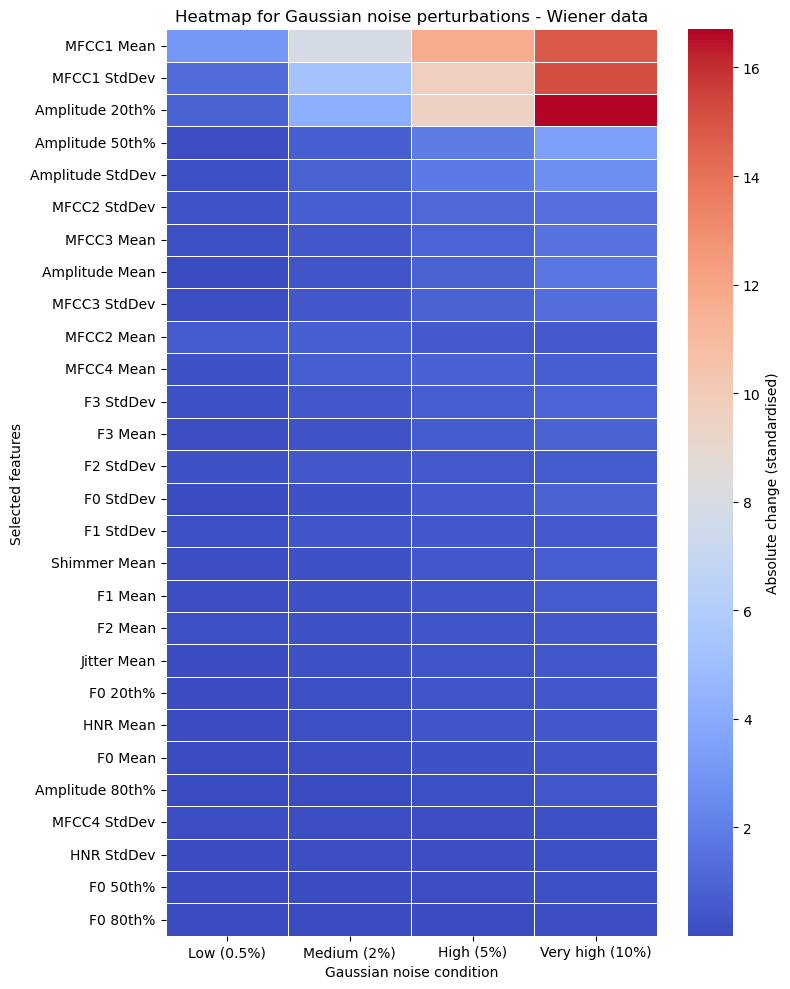

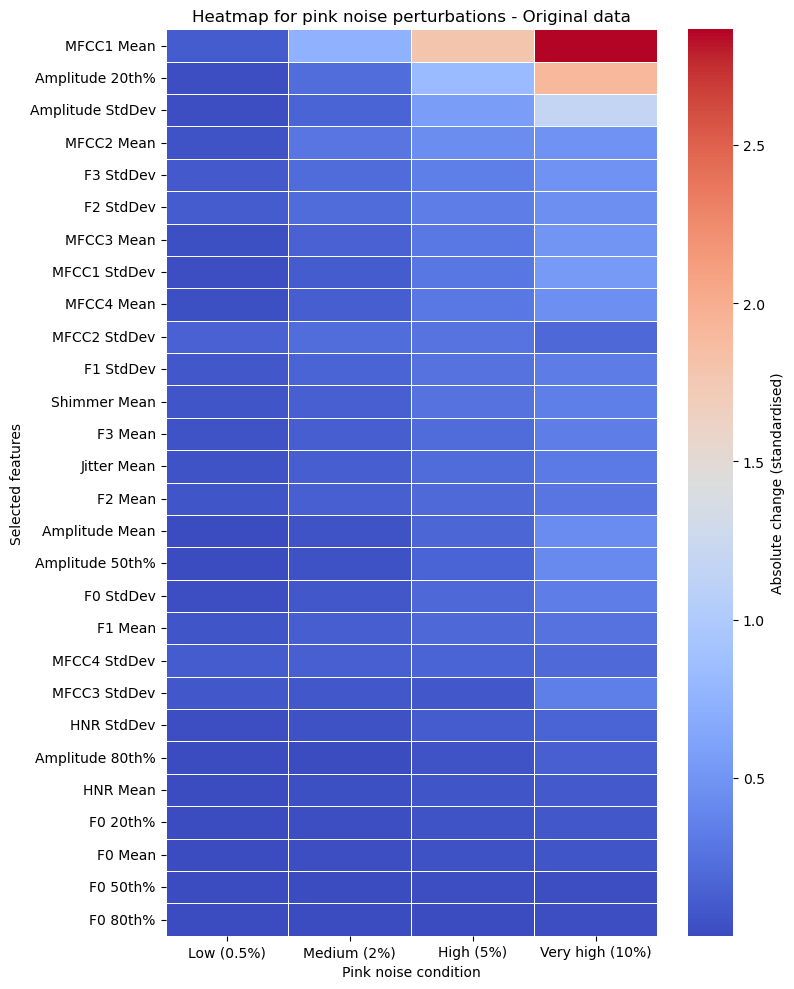

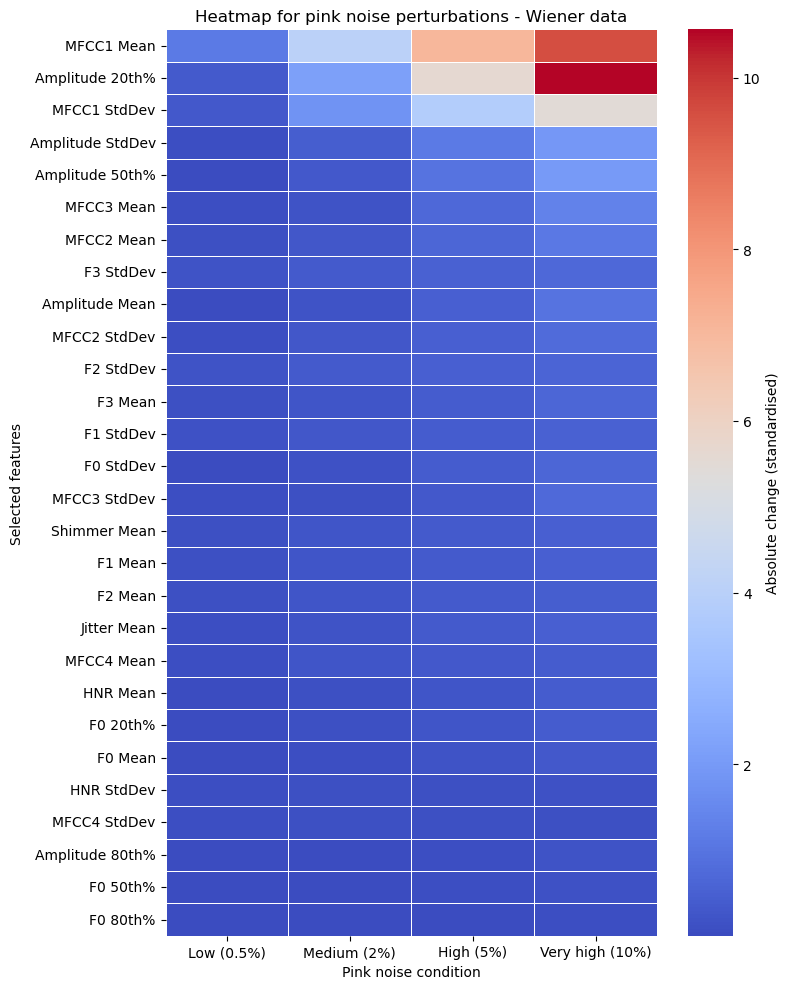

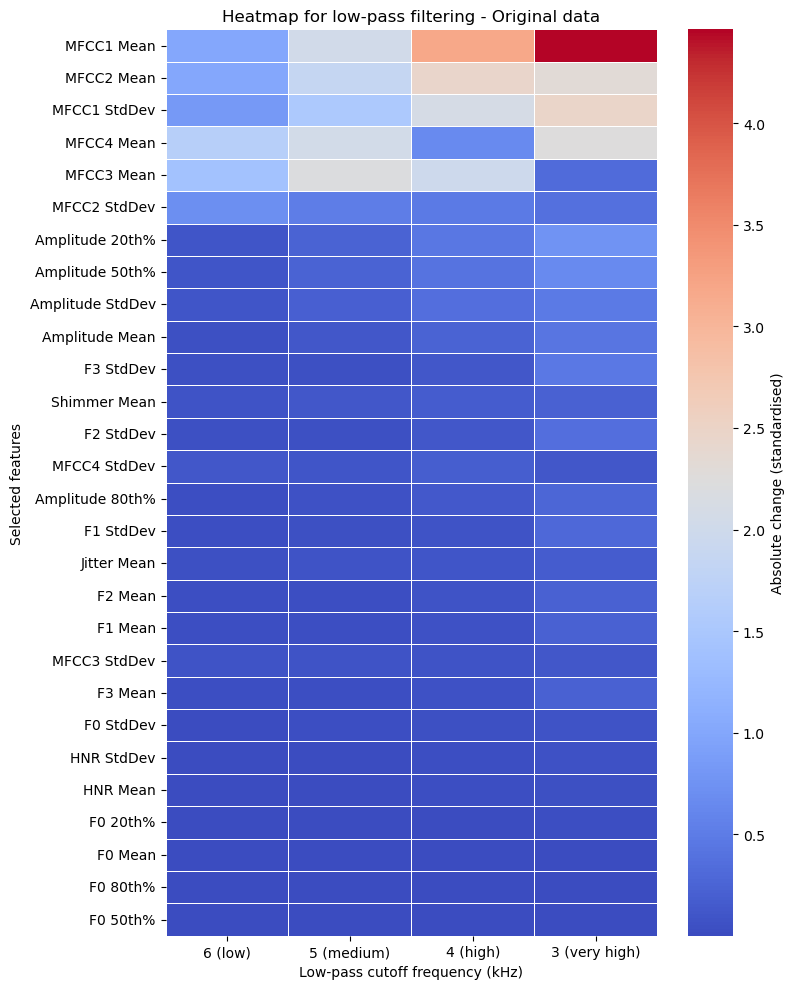

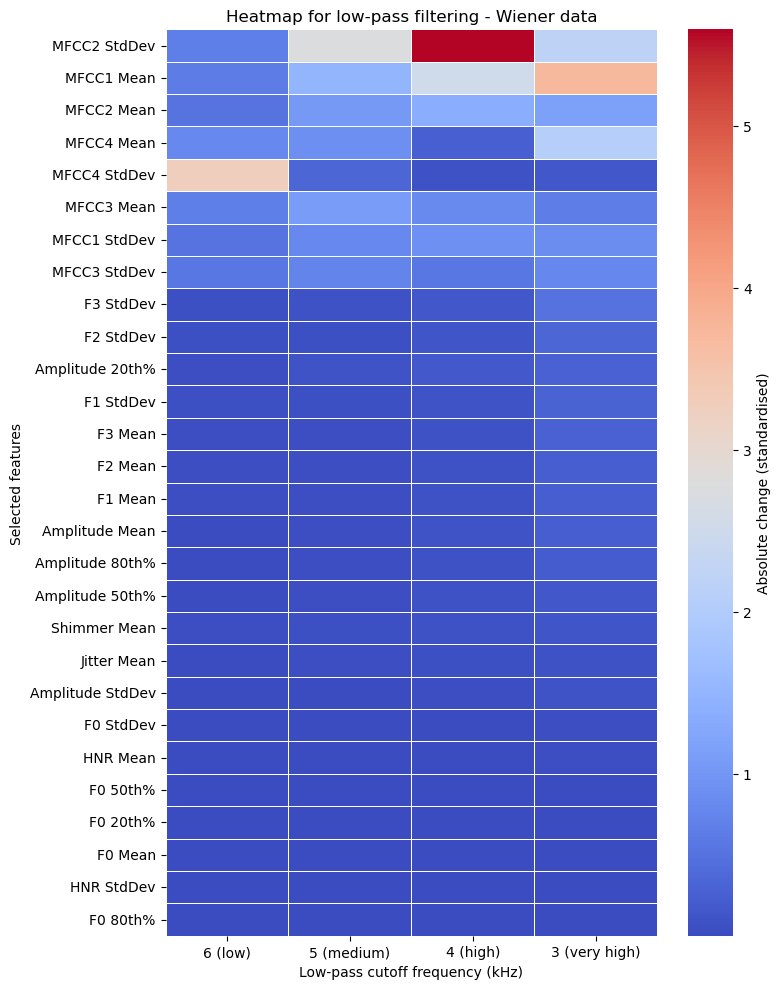

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# =========================
# Paths
# =========================
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

# =========================
# Selected features
# =========================
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Configuratie
# =========================
ROBUSTNESS_CONFIG = {
    "intensity": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "-6 dB": {
                "original": "opensmile_intensity_-6dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_-6dB_features_pain.csv",
            },
            "-3 dB": {
                "original": "opensmile_intensity_-3dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_-3dB_features_pain.csv",
            },
            "+3 dB": {
                "original": "opensmile_intensity_3dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_3dB_features_pain.csv",
            },
            "+6 dB": {
                "original": "opensmile_intensity_6dB_features_pain_original.csv",
                "wiener": "opensmile_intensity_6dB_features_pain.csv",
            },
        },
        "xlabel": "Intensity perturbations",
        "title": "Heatmap for intensity perturbations",
    },
    "gaussian_noise": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_low_gaussian_features_pain_original.csv",
                "wiener": "opensmile_low_gaussian_features_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_medium_gaussian_features_pain_original.csv",
                "wiener": "opensmile_medium_gaussian_features_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_high_gaussian_features_pain_original.csv",
                "wiener": "opensmile_high_gaussian_features_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_very_high_gaussian_features_pain_original.csv",
                "wiener": "opensmile_very_high_gaussian_features_pain.csv",
            },
        },
        "xlabel": "Gaussian noise condition",
        "title": "Heatmap for Gaussian noise perturbations",
    },
    "pink_noise": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_low_pink_features_pain_original.csv",
                "wiener": "opensmile_low_pink_features_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_medium_pink_features_pain_original.csv",
                "wiener": "opensmile_medium_pink_features_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_high_pink_features_pain_original.csv",
                "wiener": "opensmile_high_pink_features_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_very_high_pink_features_pain_original.csv",
                "wiener": "opensmile_very_high_pink_features_pain.csv",
            },
        },
        "xlabel": "Pink noise condition",
        "title": "Heatmap for pink noise perturbations",
    },
    "lowpass": {
        "original": "opensmile_original_features_pain_original.csv",
        "wiener": "opensmile_wiener_features_pain.csv",
        "conditions": {
            "6 (low)": {
                "original": "opensmile_low_lowpass_features_pain_original.csv",
                "wiener": "opensmile_low_lowpass_features_pain.csv",
            },
            "5 (medium)": {
                "original": "opensmile_medium_lowpass_features_pain_original.csv",
                "wiener": "opensmile_medium_lowpass_features_pain.csv",
            },
            "4 (high)": {
                "original": "opensmile_high_lowpass_features_pain_original.csv",
                "wiener": "opensmile_high_lowpass_features_pain.csv",
            },
            "3 (very high)": {
                "original": "opensmile_very_high_lowpass_features_pain_original.csv",
                "wiener": "opensmile_very_high_lowpass_features_pain.csv",
            },
        },
        "xlabel": "Low-pass cutoff frequency (kHz)",
        "title": "Heatmap for low-pass filtering",
    },
}

EXCLUDE_COLS = ["participant_id", "filename", "file_path", "name"]


# =========================
# Functies
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def validate_matching_ids(reference_df, comparison_dfs):
    reference_ids = reference_df[["participant_id", "filename"]]

    for name, df in comparison_dfs.items():
        current_ids = df[["participant_id", "filename"]]
        if not reference_ids.equals(current_ids):
            raise ValueError(f"Mismatch in {name}")


def get_selected_feature_cols(df, selected_features_dict):
    missing_features = [col for col in selected_features_dict.values() if col not in df.columns]
    if missing_features:
        raise ValueError(f"Deze selected features ontbreken in de data:\n{missing_features}")
    return list(selected_features_dict.values())


def standardize_against_reference(dfs, feature_cols, reference_key="original"):
    scaler = StandardScaler()
    scaler.fit(dfs[reference_key][feature_cols])

    dfs_std = {}
    for key, df in dfs.items():
        df_std = df.copy()
        df_std[feature_cols] = scaler.transform(df[feature_cols])
        dfs_std[key] = df_std

    return dfs_std


def compute_abs_diff_heatmap_df(dfs_std, feature_cols, condition_order, reference_key="original"):
    original_features = dfs_std[reference_key][feature_cols]
    abs_diff_means = {}

    for condition in condition_order:
        perturbed_features = dfs_std[condition][feature_cols]
        abs_diff = np.abs(perturbed_features - original_features)
        abs_diff_means[condition] = abs_diff.mean(axis=0)

    heatmap_df = pd.DataFrame(abs_diff_means, index=feature_cols)
    heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
    heatmap_df = heatmap_df.drop(columns=["mean_change"])

    return heatmap_df


def rename_heatmap_index(heatmap_df, selected_features_dict):
    reverse_mapping = {v: k for k, v in selected_features_dict.items()}
    heatmap_df = heatmap_df.copy()
    heatmap_df.index = [reverse_mapping.get(idx, idx) for idx in heatmap_df.index]
    return heatmap_df


def plot_heatmap(
    heatmap_df,
    title,
    xlabel,
    ylabel="Selected features",
    figsize=(8, 10)
):
    plt.figure(figsize=figsize)
    sns.heatmap(
        heatmap_df,
        cmap="coolwarm",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Absolute change (standardised)"},
        annot=False
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def run_robustness_evaluation_selected_features(
    base_path,
    config,
    data_type,
    selected_features_dict,
    save_csv=False
):
    """
    data_type = 'original' of 'wiener'
    """
    files = {
        "original": base_path / config[data_type]
    }

    for condition_name, paths in config["conditions"].items():
        files[condition_name] = base_path / paths[data_type]

    dfs = {name: load_and_sort_csv(path) for name, path in files.items()}

    validate_matching_ids(
        reference_df=dfs["original"],
        comparison_dfs={k: v for k, v in dfs.items() if k != "original"}
    )

    feature_cols = get_selected_feature_cols(dfs["original"], selected_features_dict)
    dfs_std = standardize_against_reference(dfs, feature_cols, reference_key="original")

    condition_order = list(config["conditions"].keys())
    heatmap_df = compute_abs_diff_heatmap_df(
        dfs_std=dfs_std,
        feature_cols=feature_cols,
        condition_order=condition_order,
        reference_key="original"
    )

    heatmap_df = rename_heatmap_index(heatmap_df, selected_features_dict)

    if save_csv:
        output_name = f"robustness_selected_features_{data_type}_{config['title'].lower().replace(' ', '_')}.csv"
        heatmap_df.to_csv(base_path / output_name)

    plot_heatmap(
        heatmap_df=heatmap_df,
        title=f"{config['title']} - {data_type.capitalize()} data",
        xlabel=config["xlabel"]
    )

    return heatmap_df


# =========================
# Alles runnen
# =========================
results_selected = {}

for perturbation_name, config in ROBUSTNESS_CONFIG.items():
    results_selected[(perturbation_name, "original")] = run_robustness_evaluation_selected_features(
        base_path=BASE_PATH,
        config=config,
        data_type="original",
        selected_features_dict=selected_features,
        save_csv=False
    )

    results_selected[(perturbation_name, "wiener")] = run_robustness_evaluation_selected_features(
        base_path=BASE_PATH,
        config=config,
        data_type="wiener",
        selected_features_dict=selected_features,
        save_csv=False
    )